# Day 12 – PCA + Dimensionality Reduction
### 20-Day ML Revision Planner | Phase: Advanced ML

**Topics covered:**
1. Covariance Matrix
2. Eigenvalues & Eigenvectors
3. Variance & Orthogonality
4. The PCA Pipeline (High Dimensions → Covariance → Eigenvectors → Principal Components → Reduced Dimensions)
5. Coding: Reduce a High-Dimensional Dataset to 2D with PCA
6. t-SNE (Conceptual + Practical)
7. UMAP (Conceptual)
8. Interview Questions
9. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("UMAP available:", UMAP_AVAILABLE)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP available: True


## 1. Covariance Matrix (Recap from Day 3, Extended to Multiple Dimensions)

### What?
For a dataset with $n$ features, the **covariance matrix** $\Sigma \in \mathbb{R}^{n \times n}$ captures how every pair of features varies together:

$$\Sigma_{ij} = \text{Cov}(X_i, X_j) = E[(X_i - \mu_i)(X_j - \mu_j)]$$

- **Diagonal entries**: variance of each individual feature.
- **Off-diagonal entries**: covariance between feature pairs (recall Day 3).

### Why?
PCA's entire goal is to find directions in feature space along which the data **varies the most** — and the covariance matrix is exactly the mathematical object that encodes "how the data spreads out and co-varies" across all features simultaneously.

### How?
For centered data $X$ (mean-subtracted), the covariance matrix is computed as:
$$\Sigma = \frac{1}{m-1} X^T X$$
(recall Day 1's matrix multiplication — this is a matrix "self-multiplication" that produces all pairwise feature relationships at once).


True covariance matrix used to generate the data:
 [[3.  2.  0.5]
 [2.  2.  0.3]
 [0.5 0.3 1. ]]

Covariance matrix computed from the sampled data:
 [[2.875 1.836 0.568]
 [1.836 1.821 0.306]
 [0.568 0.306 1.066]]

np.cov() for verification:
 [[2.875 1.836 0.568]
 [1.836 1.821 0.306]
 [0.568 0.306 1.066]]


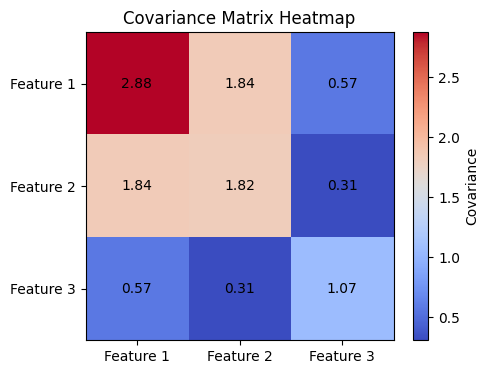

In [2]:
# Compute a covariance matrix by hand and visualize it as a heatmap
np.random.seed(1)
mean = [0, 0, 0]
cov_true = [[3, 2, 0.5], [2, 2, 0.3], [0.5, 0.3, 1]]
X_demo = np.random.multivariate_normal(mean, cov_true, 500)

X_centered = X_demo - X_demo.mean(axis=0)
cov_computed = (X_centered.T @ X_centered) / (len(X_demo) - 1)

print("True covariance matrix used to generate the data:\n", np.array(cov_true))
print("\nCovariance matrix computed from the sampled data:\n", np.round(cov_computed, 3))
print("\nnp.cov() for verification:\n", np.round(np.cov(X_demo.T), 3))

plt.figure(figsize=(5, 4))
plt.imshow(cov_computed, cmap='coolwarm')
plt.colorbar(label='Covariance')
plt.xticks([0,1,2], ['Feature 1', 'Feature 2', 'Feature 3'])
plt.yticks([0,1,2], ['Feature 1', 'Feature 2', 'Feature 3'])
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cov_computed[i,j]:.2f}", ha='center', va='center')
plt.title("Covariance Matrix Heatmap")
plt.show()


## 2. Eigenvalues & Eigenvectors

### What?
For a square matrix $A$ (here, our covariance matrix $\Sigma$), an **eigenvector** $\mathbf{v}$ is a special direction that $A$ only **scales** (never rotates):

$$\Sigma \mathbf{v} = \lambda \mathbf{v}$$

where $\lambda$ (a scalar) is the corresponding **eigenvalue** — how much that direction gets stretched.

### Why?
When $A = \Sigma$ (the covariance matrix):
- The **eigenvectors** of $\Sigma$ point in the directions of **maximum variance** in the data — these become PCA's **principal components**.
- The **eigenvalues** tell you **how much variance** lies along each corresponding eigenvector — bigger eigenvalue = more important direction.

### How?
Eigenvectors of a (symmetric) covariance matrix are always **orthogonal** to each other (see next section) — meaning PCA finds a set of **uncorrelated** directions that together capture all the data's spread, ranked from most to least important.


In [3]:
# Compute eigenvalues and eigenvectors of our covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_computed)  # eigh for symmetric matrices, returns sorted ascending

# Sort descending (largest eigenvalue = most important direction, PCA convention)
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues (variance captured by each principal direction), sorted descending:")
print(eigenvalues)
print("\nCorresponding eigenvectors (each COLUMN is a principal direction):")
print(eigenvectors)

# Verify the defining equation: Sigma @ v = lambda * v
for i in range(3):
    v = eigenvectors[:, i]
    lhs = cov_computed @ v
    rhs = eigenvalues[i] * v
    print(f"\nEigenvector {i+1}: Sigma @ v = {np.round(lhs, 3)}, lambda * v = {np.round(rhs, 3)} -- match!")


Eigenvalues (variance captured by each principal direction), sorted descending:
[4.3817 0.961  0.4202]

Corresponding eigenvectors (each COLUMN is a principal direction):
[[-0.787  -0.0412 -0.6155]
 [-0.5872 -0.256   0.7679]
 [-0.1892  0.9658  0.1773]]

Eigenvector 1: Sigma @ v = [-3.449 -2.573 -0.829], lambda * v = [-3.449 -2.573 -0.829] -- match!

Eigenvector 2: Sigma @ v = [-0.04  -0.246  0.928], lambda * v = [-0.04  -0.246  0.928] -- match!

Eigenvector 3: Sigma @ v = [-0.259  0.323  0.075], lambda * v = [-0.259  0.323  0.075] -- match!


## 3. Variance & Orthogonality

### What?
- **Variance explained**: the proportion of total variance captured by each principal component, computed as $\frac{\lambda_i}{\sum_j \lambda_j}$.
- **Orthogonality**: two vectors are orthogonal if their dot product is zero (recall Day 1) — geometrically, they're perpendicular, representing **completely uncorrelated** directions.

### Why?
Because PCA's principal components are **orthogonal by construction**, each one captures a distinct, non-redundant "axis of variation" in the data — there's no overlap in the information each component represents.

### How?
Verify orthogonality by checking that the dot product between any two distinct eigenvectors is (numerically) zero.


In [4]:
# Verify orthogonality of the eigenvectors, and compute variance explained
print("Dot products between pairs of eigenvectors (should be ~0 for orthogonal vectors):")
for i in range(3):
    for j in range(i+1, 3):
        dot = eigenvectors[:, i] @ eigenvectors[:, j]
        print(f"  v{i+1} . v{j+1} = {dot:.6f}")

total_variance = eigenvalues.sum()
variance_explained = eigenvalues / total_variance
print("\nVariance explained by each principal component:")
for i, ve in enumerate(variance_explained):
    print(f"  PC{i+1}: {ve:.2%}  (eigenvalue = {eigenvalues[i]:.3f})")
print(f"\nCumulative variance explained by top 2 components: {variance_explained[:2].sum():.2%}")


Dot products between pairs of eigenvectors (should be ~0 for orthogonal vectors):
  v1 . v2 = 0.000000
  v1 . v3 = -0.000000
  v2 . v3 = -0.000000

Variance explained by each principal component:
  PC1: 76.03%  (eigenvalue = 4.382)
  PC2: 16.68%  (eigenvalue = 0.961)
  PC3: 7.29%  (eigenvalue = 0.420)

Cumulative variance explained by top 2 components: 92.71%


## 4. The PCA Pipeline: High Dimensions → Covariance → Eigenvectors → Principal Components → Reduced Dimensions

### What?
Putting it all together, PCA follows this exact pipeline:

$$\text{High-Dim Data} \;\to\; \text{Standardize} \;\to\; \text{Covariance Matrix} \;\to\; \text{Eigenvectors/Eigenvalues} \;\to\; \text{Sort by Eigenvalue} \;\to\; \text{Project onto Top-}k\text{ Eigenvectors} \;\to\; \text{Reduced Dimensions}$$

### Why?
This gives us a way to **compress** data into fewer dimensions while **retaining as much variance (information) as possible** — useful for visualization (reducing to 2D/3D), speeding up downstream models, reducing noise, and fighting the **curse of dimensionality** (foreshadowing Day 13).

### How? — Step by step
1. **Standardize** the data (mean 0, unit variance — recall Day 4; essential since PCA is scale-sensitive, just like distance-based methods).
2. Compute the **covariance matrix**.
3. Compute its **eigenvalues and eigenvectors**.
4. **Sort** eigenvectors by descending eigenvalue.
5. **Select the top $k$** eigenvectors (principal components) — often chosen to retain e.g. 90-95% of cumulative variance.
6. **Project** the original data onto these top $k$ eigenvectors: $X_{reduced} = X_{standardized} \cdot V_k$.


In [5]:
# Implement PCA FROM SCRATCH, following the exact pipeline above, then verify against sklearn
class PCAScratch:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit_transform(self, X):
        # Step 1: standardize (assumes X is already standardized here for clarity; see full pipeline below)
        X_centered = X - X.mean(axis=0)

        # Step 2: covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Step 3: eigenvalues/eigenvectors
        eigvals, eigvecs = np.linalg.eigh(cov_matrix)

        # Step 4: sort descending
        idx = np.argsort(eigvals)[::-1]
        eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

        # Step 5: select top-k components
        self.components_ = eigvecs[:, :self.n_components]
        self.explained_variance_ = eigvals[:self.n_components]
        self.explained_variance_ratio_ = eigvals[:self.n_components] / eigvals.sum()

        # Step 6: project
        return X_centered @ self.components_


# Apply to our 3D demo data, reduce to 2D
pca_scratch = PCAScratch(n_components=2)
X_scratch_reduced = pca_scratch.fit_transform(X_demo)

# Compare against sklearn's PCA
pca_sklearn = PCA(n_components=2)
X_sklearn_reduced = pca_sklearn.fit_transform(X_demo - X_demo.mean(axis=0))

print("Scratch PCA explained variance ratio:", pca_scratch.explained_variance_ratio_)
print("sklearn PCA explained variance ratio:", pca_sklearn.explained_variance_ratio_)
print("\n--> Matching explained variance ratios confirm our from-scratch implementation is correct")
print("    (signs of individual components may flip, which is mathematically inconsequential).")


Scratch PCA explained variance ratio: [0.7603 0.1668]
sklearn PCA explained variance ratio: [0.7603 0.1668]

--> Matching explained variance ratios confirm our from-scratch implementation is correct
    (signs of individual components may flip, which is mathematically inconsequential).


## 5. Coding Practice — Reduce a High-Dimensional Dataset to 2D with PCA and Visualize

**Dataset:** Breast Cancer Wisconsin (30 features) — reduce to 2D for visualization while preserving as much class-separating structure as possible.


In [6]:
# Load and standardize the Breast Cancer dataset (30 features -- genuinely high-dimensional)
data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Original dimensionality: {X_scaled.shape[1]} features")


Original dimensionality: 30 features


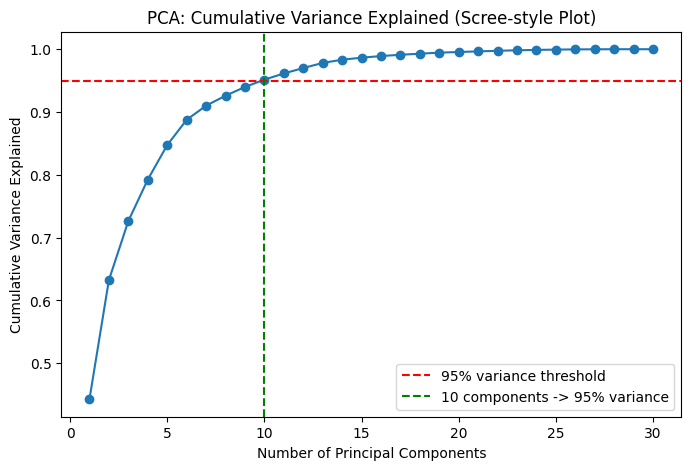

Components needed to retain 95% of variance: 10 (out of 30 original features)
Variance explained by just the first 2 components: 63.24%


In [7]:
# Full PCA pipeline: fit on all components first to inspect variance explained
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
plt.axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components -> 95% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA: Cumulative Variance Explained (Scree-style Plot)")
plt.legend()
plt.show()

print(f"Components needed to retain 95% of variance: {n_components_95} (out of {X_scaled.shape[1]} original features)")
print(f"Variance explained by just the first 2 components: {cumulative_variance[1]:.2%}")


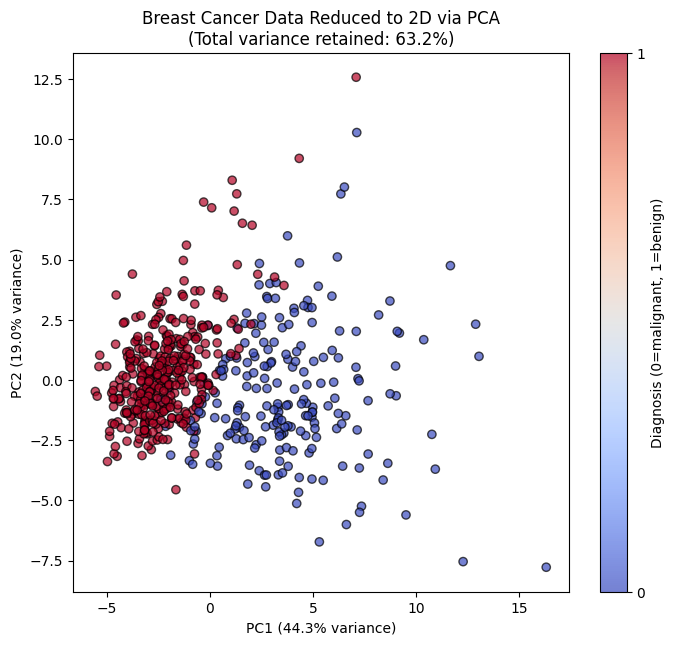

--> Even after discarding 28 of the 30 original dimensions, the two classes remain
    visually well-separated -- PCA preserved the structure most relevant to the data's spread.


In [8]:
# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolor='k')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.title(f"Breast Cancer Data Reduced to 2D via PCA\n(Total variance retained: {pca_2d.explained_variance_ratio_.sum():.1%})")
plt.colorbar(scatter, label='Diagnosis (0=malignant, 1=benign)', ticks=[0,1])
plt.show()

print("--> Even after discarding 28 of the 30 original dimensions, the two classes remain")
print("    visually well-separated -- PCA preserved the structure most relevant to the data's spread.")


In [9]:
# Interpret WHAT the principal components represent: examine the loadings (eigenvector weights)
loadings = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=data.feature_names)
top_pc1_features = loadings['PC1'].abs().sort_values(ascending=False).head(5)
top_pc2_features = loadings['PC2'].abs().sort_values(ascending=False).head(5)

print("Top 5 features contributing most to PC1 (by absolute loading):")
print(loadings.loc[top_pc1_features.index, 'PC1'])
print("\nTop 5 features contributing most to PC2 (by absolute loading):")
print(loadings.loc[top_pc2_features.index, 'PC2'])
print("\n--> PC1 typically aggregates 'overall size/severity' measurements (radius, perimeter, area,")
print("    concavity), since these tend to be highly correlated and dominate the variance.")


Top 5 features contributing most to PC1 (by absolute loading):
mean concave points     0.2609
mean concavity          0.2584
worst concave points    0.2509
mean compactness        0.2393
worst perimeter         0.2366
Name: PC1, dtype: float64

Top 5 features contributing most to PC2 (by absolute loading):
mean fractal dimension     0.3666
fractal dimension error    0.2801
worst fractal dimension    0.2753
mean radius               -0.2339
compactness error          0.2327
Name: PC2, dtype: float64

--> PC1 typically aggregates 'overall size/severity' measurements (radius, perimeter, area,
    concavity), since these tend to be highly correlated and dominate the variance.


## 6. t-SNE (t-distributed Stochastic Neighbor Embedding)

### What?
Unlike PCA (a **linear** technique focused on preserving global variance), **t-SNE** is a **non-linear** dimensionality reduction technique focused on preserving **local neighborhood structure** — points that are close together in high dimensions should remain close in the low-dimensional embedding.

### Why?
t-SNE often produces much more visually distinct, well-separated clusters than PCA for complex/non-linear data (e.g., image or text embeddings), making it extremely popular for **visualization**.

### How? — Important Caveats
- **Not primarily for feature engineering/general dimensionality reduction** for downstream ML models — mainly a visualization tool.
- **Distances between clusters and cluster SIZES in a t-SNE plot are not meaningful** — only relative local neighborhood structure is preserved, not global geometry.
- **Computationally expensive**, and results can vary noticeably with the `perplexity` hyperparameter (roughly, the expected number of close neighbors) and across different random seeds.
- Cannot easily transform *new* unseen points once fit (unlike PCA, which has an explicit linear projection).


Digits dataset: 1797 samples, 64 features (8x8 pixel images)


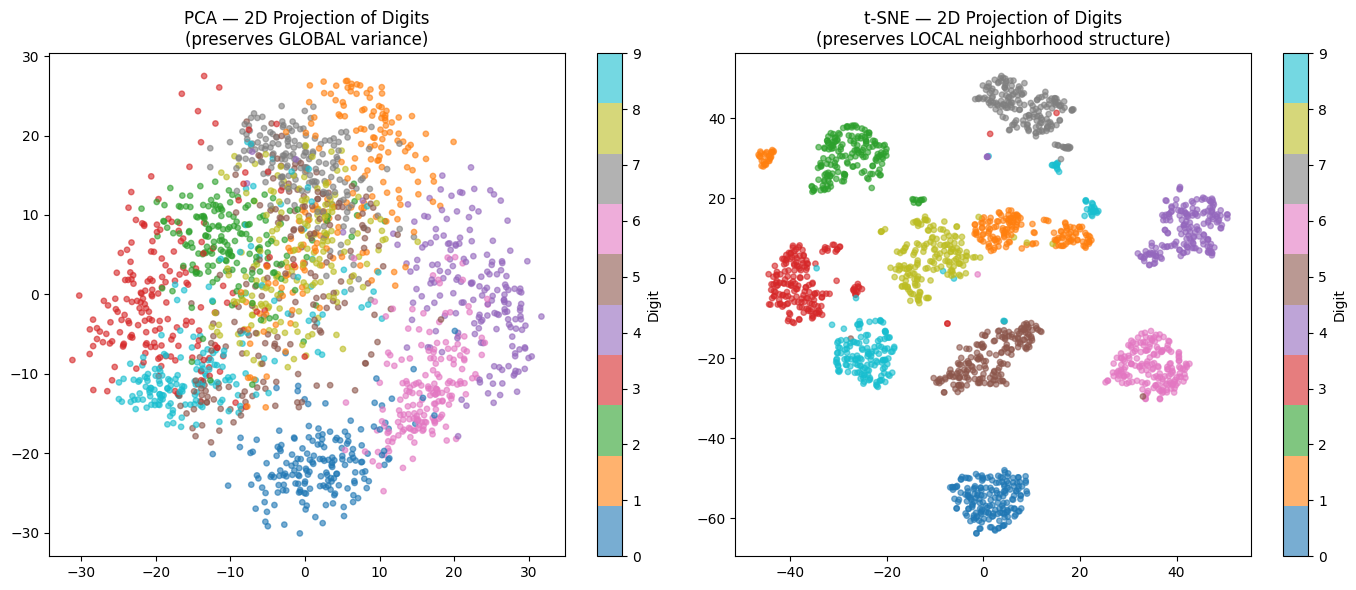

--> t-SNE typically produces much tighter, more visually distinct clusters per digit class,
    since it directly optimizes for preserving local neighbor relationships.


In [10]:
# Apply t-SNE to the Digits dataset (higher-dimensional, more dramatic non-linear structure than Breast Cancer)
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print(f"Digits dataset: {X_digits.shape[0]} samples, {X_digits.shape[1]} features (8x8 pixel images)")

# Compare PCA vs t-SNE side by side on the same data
pca_digits = PCA(n_components=2).fit_transform(X_digits)
tsne_digits = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter1 = axes[0].scatter(pca_digits[:, 0], pca_digits[:, 1], c=y_digits, cmap='tab10', alpha=0.6, s=15)
axes[0].set_title("PCA — 2D Projection of Digits\n(preserves GLOBAL variance)")
plt.colorbar(scatter1, ax=axes[0], label='Digit')

scatter2 = axes[1].scatter(tsne_digits[:, 0], tsne_digits[:, 1], c=y_digits, cmap='tab10', alpha=0.6, s=15)
axes[1].set_title("t-SNE — 2D Projection of Digits\n(preserves LOCAL neighborhood structure)")
plt.colorbar(scatter2, ax=axes[1], label='Digit')

plt.tight_layout()
plt.show()
print("--> t-SNE typically produces much tighter, more visually distinct clusters per digit class,")
print("    since it directly optimizes for preserving local neighbor relationships.")


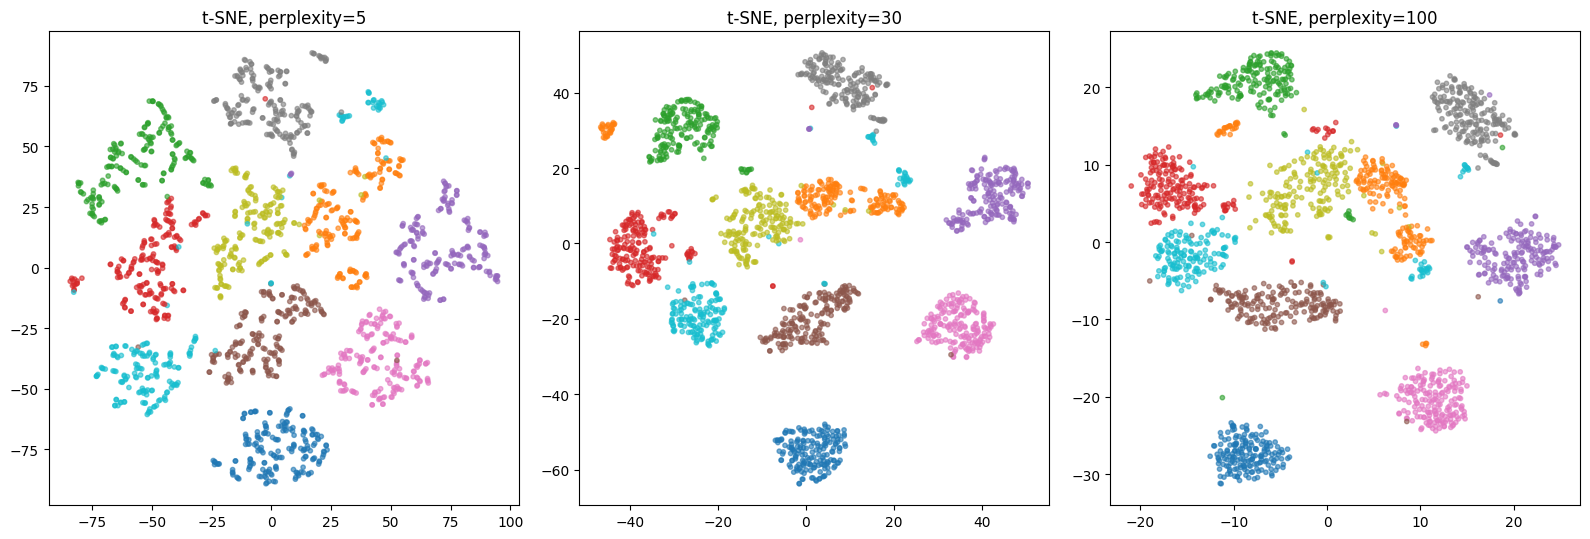

--> Low perplexity: focuses on very local structure, can fragment natural clusters.
--> High perplexity: considers more global structure, can blur fine-grained separations.


In [11]:
# Show the effect of perplexity on t-SNE embeddings
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, perplexity in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(X_digits)
    ax.scatter(tsne_p[:, 0], tsne_p[:, 1], c=y_digits, cmap='tab10', alpha=0.6, s=10)
    ax.set_title(f"t-SNE, perplexity={perplexity}")
plt.tight_layout()
plt.show()
print("--> Low perplexity: focuses on very local structure, can fragment natural clusters.")
print("--> High perplexity: considers more global structure, can blur fine-grained separations.")


## 7. UMAP (Uniform Manifold Approximation and Projection) — Conceptual Understanding

### What?
**UMAP** is another non-linear dimensionality reduction technique, conceptually similar in *purpose* to t-SNE (preserve neighborhood structure for visualization) but built on a different mathematical foundation (topological data analysis / manifold learning theory).

### Why? — How it Compares to t-SNE
- **Faster** than t-SNE, especially on large datasets — scales better.
- Better preserves **some global structure** in addition to local structure (though still primarily local-structure-focused, more so than PCA).
- Has an explicit `transform()` method for new data (unlike standard t-SNE), making it more usable in production-style pipelines.
- Key hyperparameters: `n_neighbors` (similar role to t-SNE's `perplexity` — local vs global trade-off) and `min_dist` (how tightly points are allowed to be packed in the embedding).

### How?
Conceptually: build a graph representing the data's neighborhood structure on its underlying manifold, then optimize a low-dimensional layout whose neighborhood graph best matches that structure.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


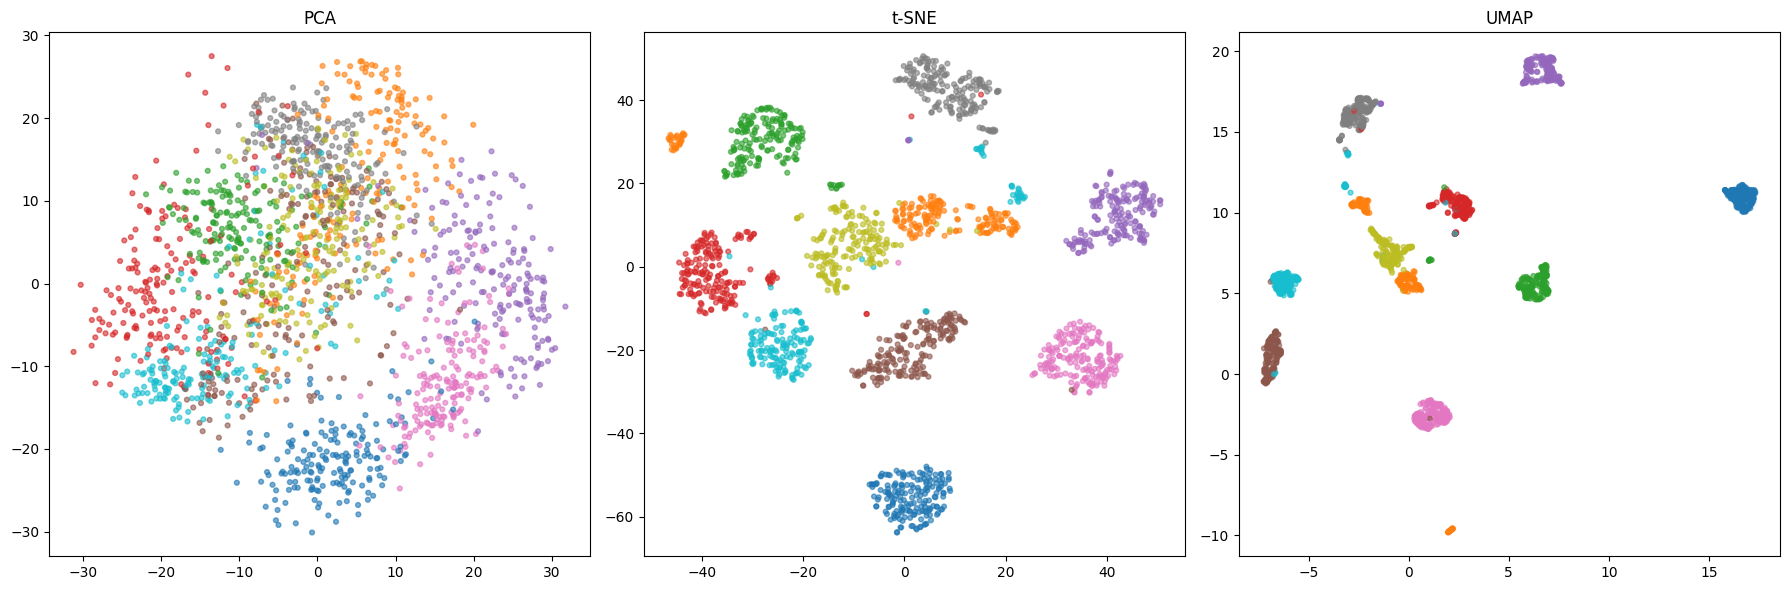

--> UMAP often produces cluster separation competitive with t-SNE, but runs faster and
    can transform new points after fitting, unlike standard t-SNE.


In [12]:
# UMAP demonstration (runs only if the umap-learn package is installed in this environment)
if UMAP_AVAILABLE:
    umap_digits = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_digits)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, (embedding, title) in zip(axes, [
        (pca_digits, "PCA"),
        (tsne_digits, "t-SNE"),
        (umap_digits, "UMAP")
    ]):
        sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=y_digits, cmap='tab10', alpha=0.6, s=12)
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print("--> UMAP often produces cluster separation competitive with t-SNE, but runs faster and")
    print("    can transform new points after fitting, unlike standard t-SNE.")
else:
    print("umap-learn is not installed in this environment.")
    print("To try it yourself: pip install umap-learn")
    print("Conceptually, you would use it exactly like PCA/t-SNE:")
    print("  import umap")
    print("  embedding = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)")


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Covariance matrix | Day 3's covariance, extended to many feature pairs at once |
| Eigenvectors/eigenvalues | Day 1's matrix operations; the mathematical machinery behind PCA |
| Orthogonality | Day 1's dot product (zero dot product = orthogonal) |
| Standardization before PCA | Day 4's standardization — PCA is scale-sensitive |
| Curse of dimensionality | Preview of Day 13's Feature Engineering & Selection |
| PCA before clustering/modeling | Can speed up and denoise inputs to Day 11's clustering or any classifier |


## 8. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Explain PCA in your own words, step by step.**
   *Hint: standardize → covariance matrix → eigenvectors/eigenvalues → sort by eigenvalue → project onto top-k components.*

2. **Why must you standardize data before applying PCA?**
   *Hint: PCA maximizes variance — features with larger scales would dominate the principal components purely due to units, not genuine importance.*

3. **What do eigenvalues and eigenvectors represent in the context of PCA?**
   *Hint: eigenvectors = directions of maximum variance (principal components); eigenvalues = amount of variance captured along each direction.*

4. **Why are principal components orthogonal to each other, and why does that matter?**
   *Hint: eigenvectors of a symmetric covariance matrix are orthogonal by construction; this ensures each component captures non-redundant, uncorrelated information.*

5. **How would you decide how many principal components to keep?**
   *Hint: cumulative explained variance ratio — commonly retain enough components to explain ~90-95% of total variance (scree plot / elbow-style analysis).*

6. **What's the key difference between PCA and t-SNE/UMAP?**
   *Hint: PCA is linear and preserves global variance/structure (and can transform new data easily); t-SNE/UMAP are non-linear, optimized for preserving local neighborhood structure, mainly for visualization.*

7. **(Bonus) Why shouldn't you interpret cluster sizes or distances between clusters in a t-SNE plot literally?**
   *Hint: t-SNE only optimizes for preserving LOCAL neighbor relationships — global distances and relative cluster sizes are not mathematically meaningful in the embedding.*


## 9. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Write the covariance matrix formula and explain what its diagonal and off-diagonal entries represent.
- [ ] Write the eigenvector equation ($\Sigma v = \lambda v$) from memory and explain what $v$ and $\lambda$ mean for PCA.
- [ ] Explain why PCA's principal components are orthogonal, and verify it numerically.
- [ ] Recite the full PCA pipeline from memory: standardize → covariance → eigen-decomposition → sort → project.
- [ ] Implement PCA from scratch and verify it matches sklearn's PCA.
- [ ] Use a cumulative explained variance plot to decide how many components to keep.
- [ ] Explain the key conceptual differences between PCA, t-SNE, and UMAP.

### 📌 Daily Output (per the planner)
A **PCA explanation with eigenvalue/eigenvector intuition** — produced throughout Sections 1-4 (with a from-scratch PCA implementation verified against sklearn) and applied hands-on in Section 5, reducing the 30-dimensional Breast Cancer dataset to 2D while retaining strong class separability, plus interpreting which original features drive each principal component.

Close this notebook and re-derive the PCA pipeline (and re-implement `PCAScratch`) from memory — that's the real test of Day 12 mastery.
